In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 


## Model evaluated:
checkpoint: `attn_cue_models/word_task_standard_v07/checkpoints/epoch=3-step=67111.ckpt`   
config: `config/binaural_attn/word_task_standard_v07.yaml`

In [2]:
ls binaural_eval/human_pilot_conds/

word_task_all_co_located_v04/        word_task_no_co_loc_v05/
word_task_half_co_loc_v05/           word_task_sans_loc_only_cue_v04/
word_task_half_co_loc_v06/           word_task_standard_v06sm_lr/
word_task_half_co_loc_v06_old_ckpt/  word_task_standard_v07/
word_task_half_co_loc_v07/           word_task_voice_loc_cue_only_v04/


In [3]:
# Path to results 

# match human pilot conditions
model_name = 'word_task_half_co_loc_v07'
output_paths = list(Path(f"binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))

stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    
    df.rename(columns={"results": "accuracy"}, inplace=True)
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')  
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)

    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [4]:
results.shape

(1603248, 13)

In [5]:
# results.shape

In [6]:
grouped_results = results.groupby(['target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'gender_cond']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()




In [7]:
grouped_results.head()

,target_azim,target_elev,distractor_azim,distractor_elev,gender_cond,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem,elevation_sep,abs_elevation_sep,elevated_source,abs_target_azim,abs_distractor_azim,azim_delta,abs_azim_delta
0,-90,-20,-90,-20,diff,0.527883,0.012571,0.069708,0.006413,0,0,co-located,90,90,0,0
1,-90,-20,-90,-20,same,0.418251,0.012421,0.181242,0.009700,0,0,co-located,90,90,0,0
2,-90,-20,-90,-10,diff,0.539290,0.012552,0.058302,0.005900,-10,10,distractor,90,90,0,0
3,-90,-20,-90,-10,same,0.441698,0.012505,0.156527,0.009150,-10,10,distractor,90,90,0,0
4,-90,-20,-90,0,diff,0.544994,0.012540,0.048796,0.005425,-20,20,distractor,90,90,0,0


In [8]:
# with open("binaural_test_manifests/expanded_all_azim_chosen_elev_az_11_29_2023.pkl", "rb") as f:
with open("binaural_test_manifests/match_human_pilot_conds.pkl", "rb") as f:
    loc_dict = pickle.load(f)
loc_df = pd.DataFrame.from_records([{'target_az':targ_loc[0], "target_elev":targ_loc[1], "distractor_az":distr_loc[0], "distractor_elev":distr_loc[1]}
                                    for (targ_loc, distr_loc) in loc_dict.values()])
print(loc_df.target_az.unique())
print(loc_df.target_elev.unique())

[  0  10  20  30  40  50  60  70  80  90 350 340 330 320 310 300 290 280
 270]
[  0 -20  10  40]


In [9]:
loc_df[(loc_df.target_elev == 0) & (loc_df.distractor_elev == 0) & (loc_df.target_az == 20) & (loc_df.distractor_az.isin([0, -10, 10, 20]))]

,target_az,target_elev,distractor_az,distractor_elev
38,20,0,0,0
39,20,0,10,0
40,20,0,20,0


In [10]:
loc_df[loc_df.target_elev.eq(0)].target_az.unique()

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 350, 340, 330,
       320, 310, 300, 290, 280, 270])

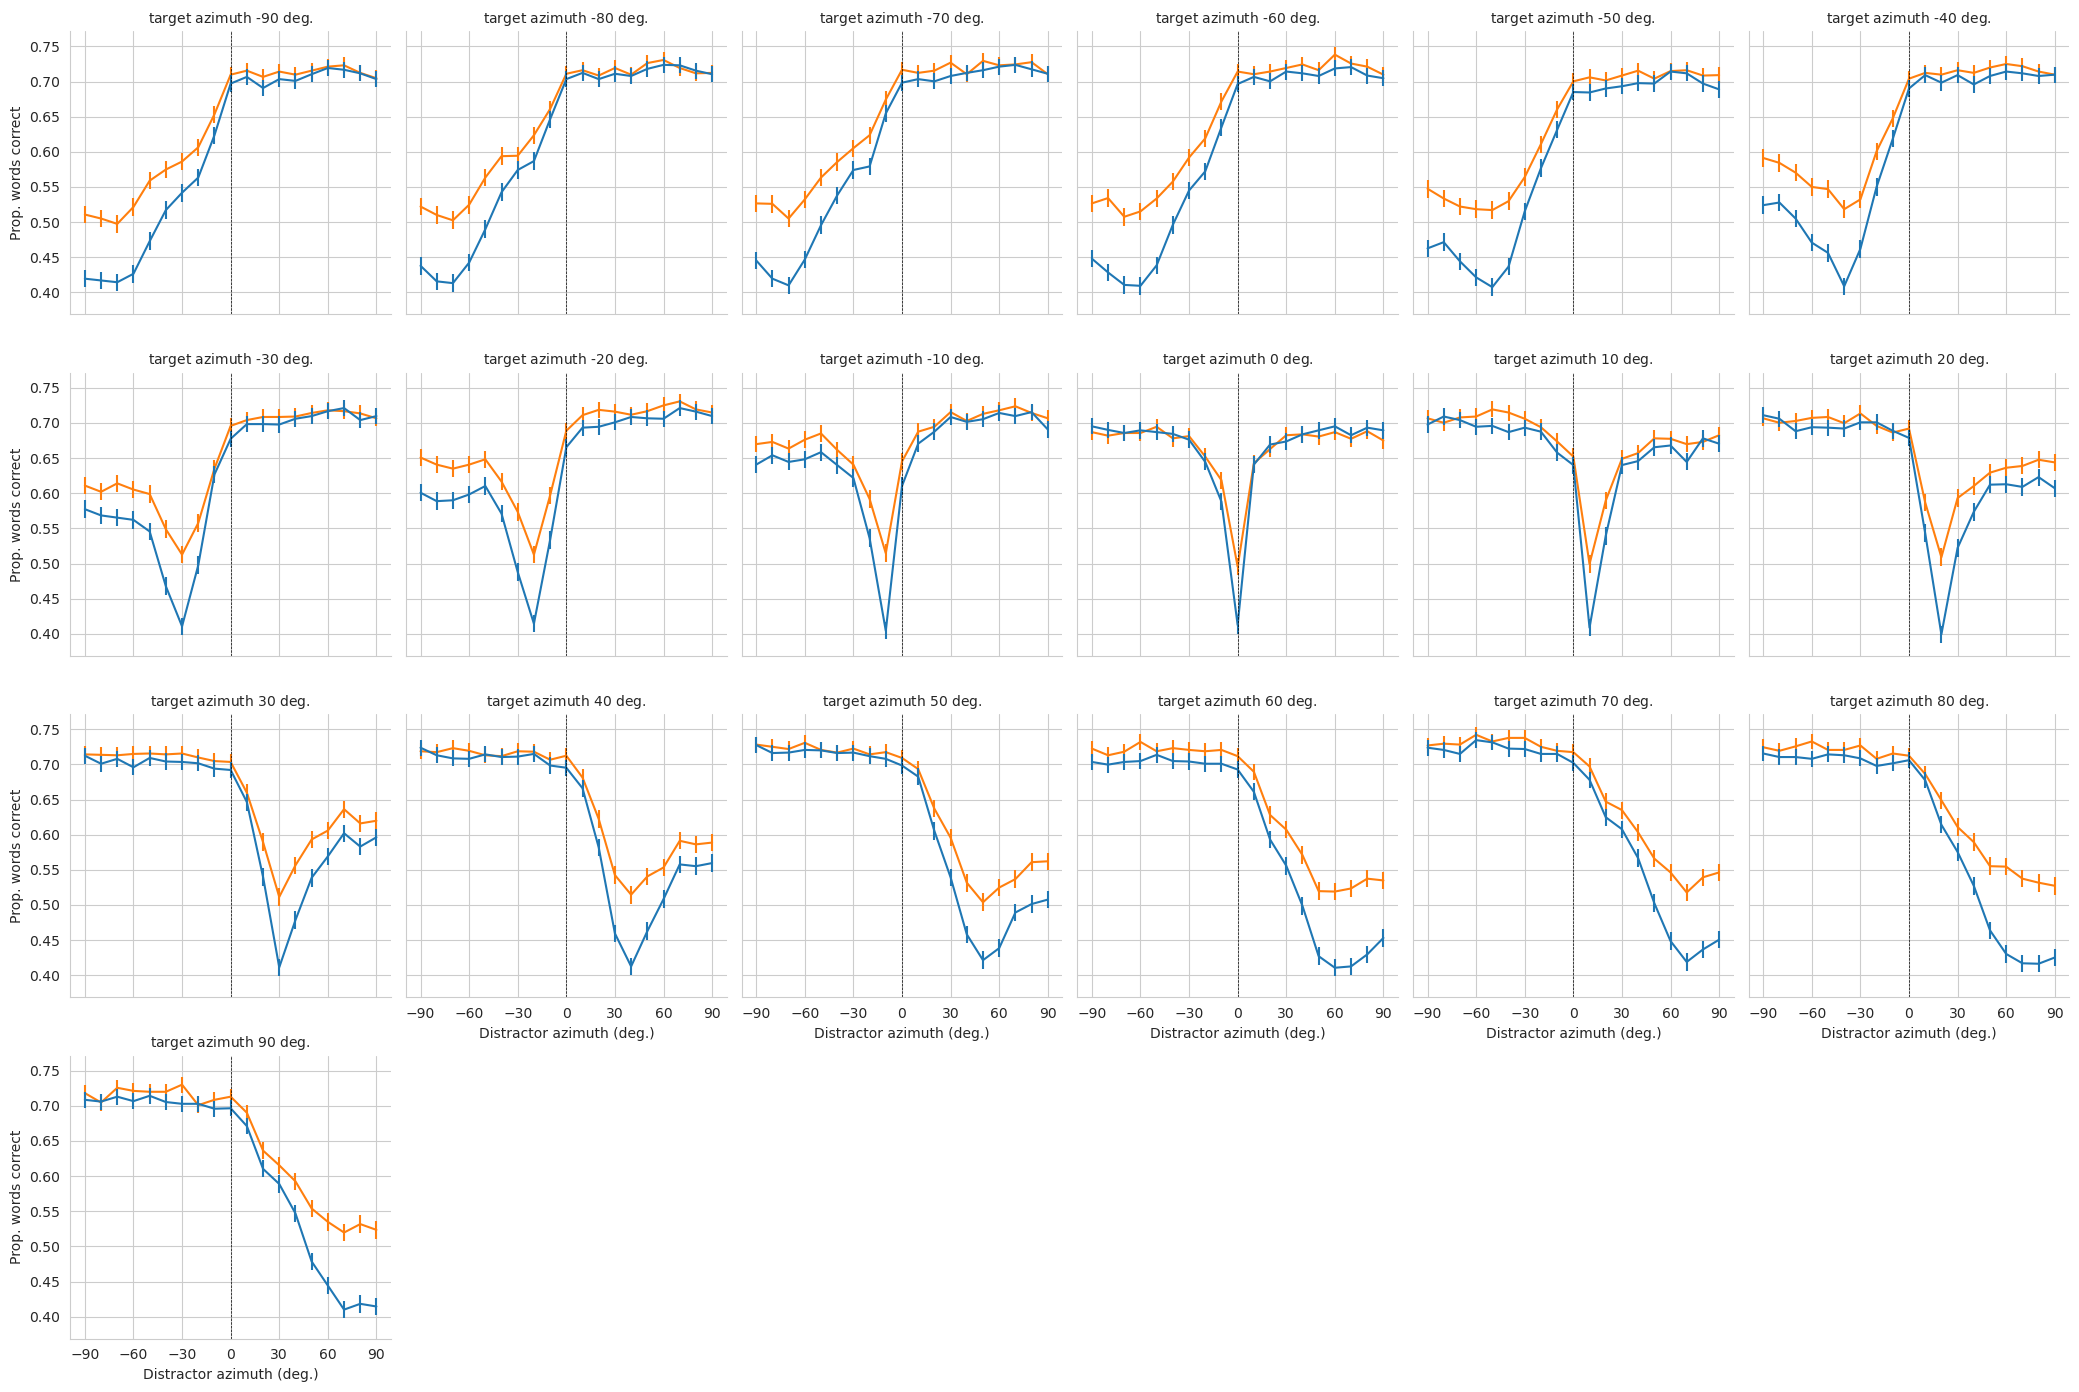

In [11]:

palette = {'same':'tab:blue', 'diff':'tab:orange'}  
sns.set_style('whitegrid')

to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)]
g = sns.relplot(data=to_plot,
                palette=palette,
                 x='distractor_azim', y='accuracy_mean', 
                 hue='gender_cond', kind='line', 
                 col='target_azim', col_wrap= 6, height=3.5)

# iterate through each facet of the facetgrid
for azim, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    # select the data for the facet
    data = to_plot[to_plot['target_azim'].eq(azim)]
    # select the data for each hue group
    for group, selected in data.groupby('gender_cond'):
        # plot the errorbar with the correct color for each group 
        
        # print(selected)
        ax.errorbar(data=selected, x="distractor_azim", y="accuracy_mean",
                     yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

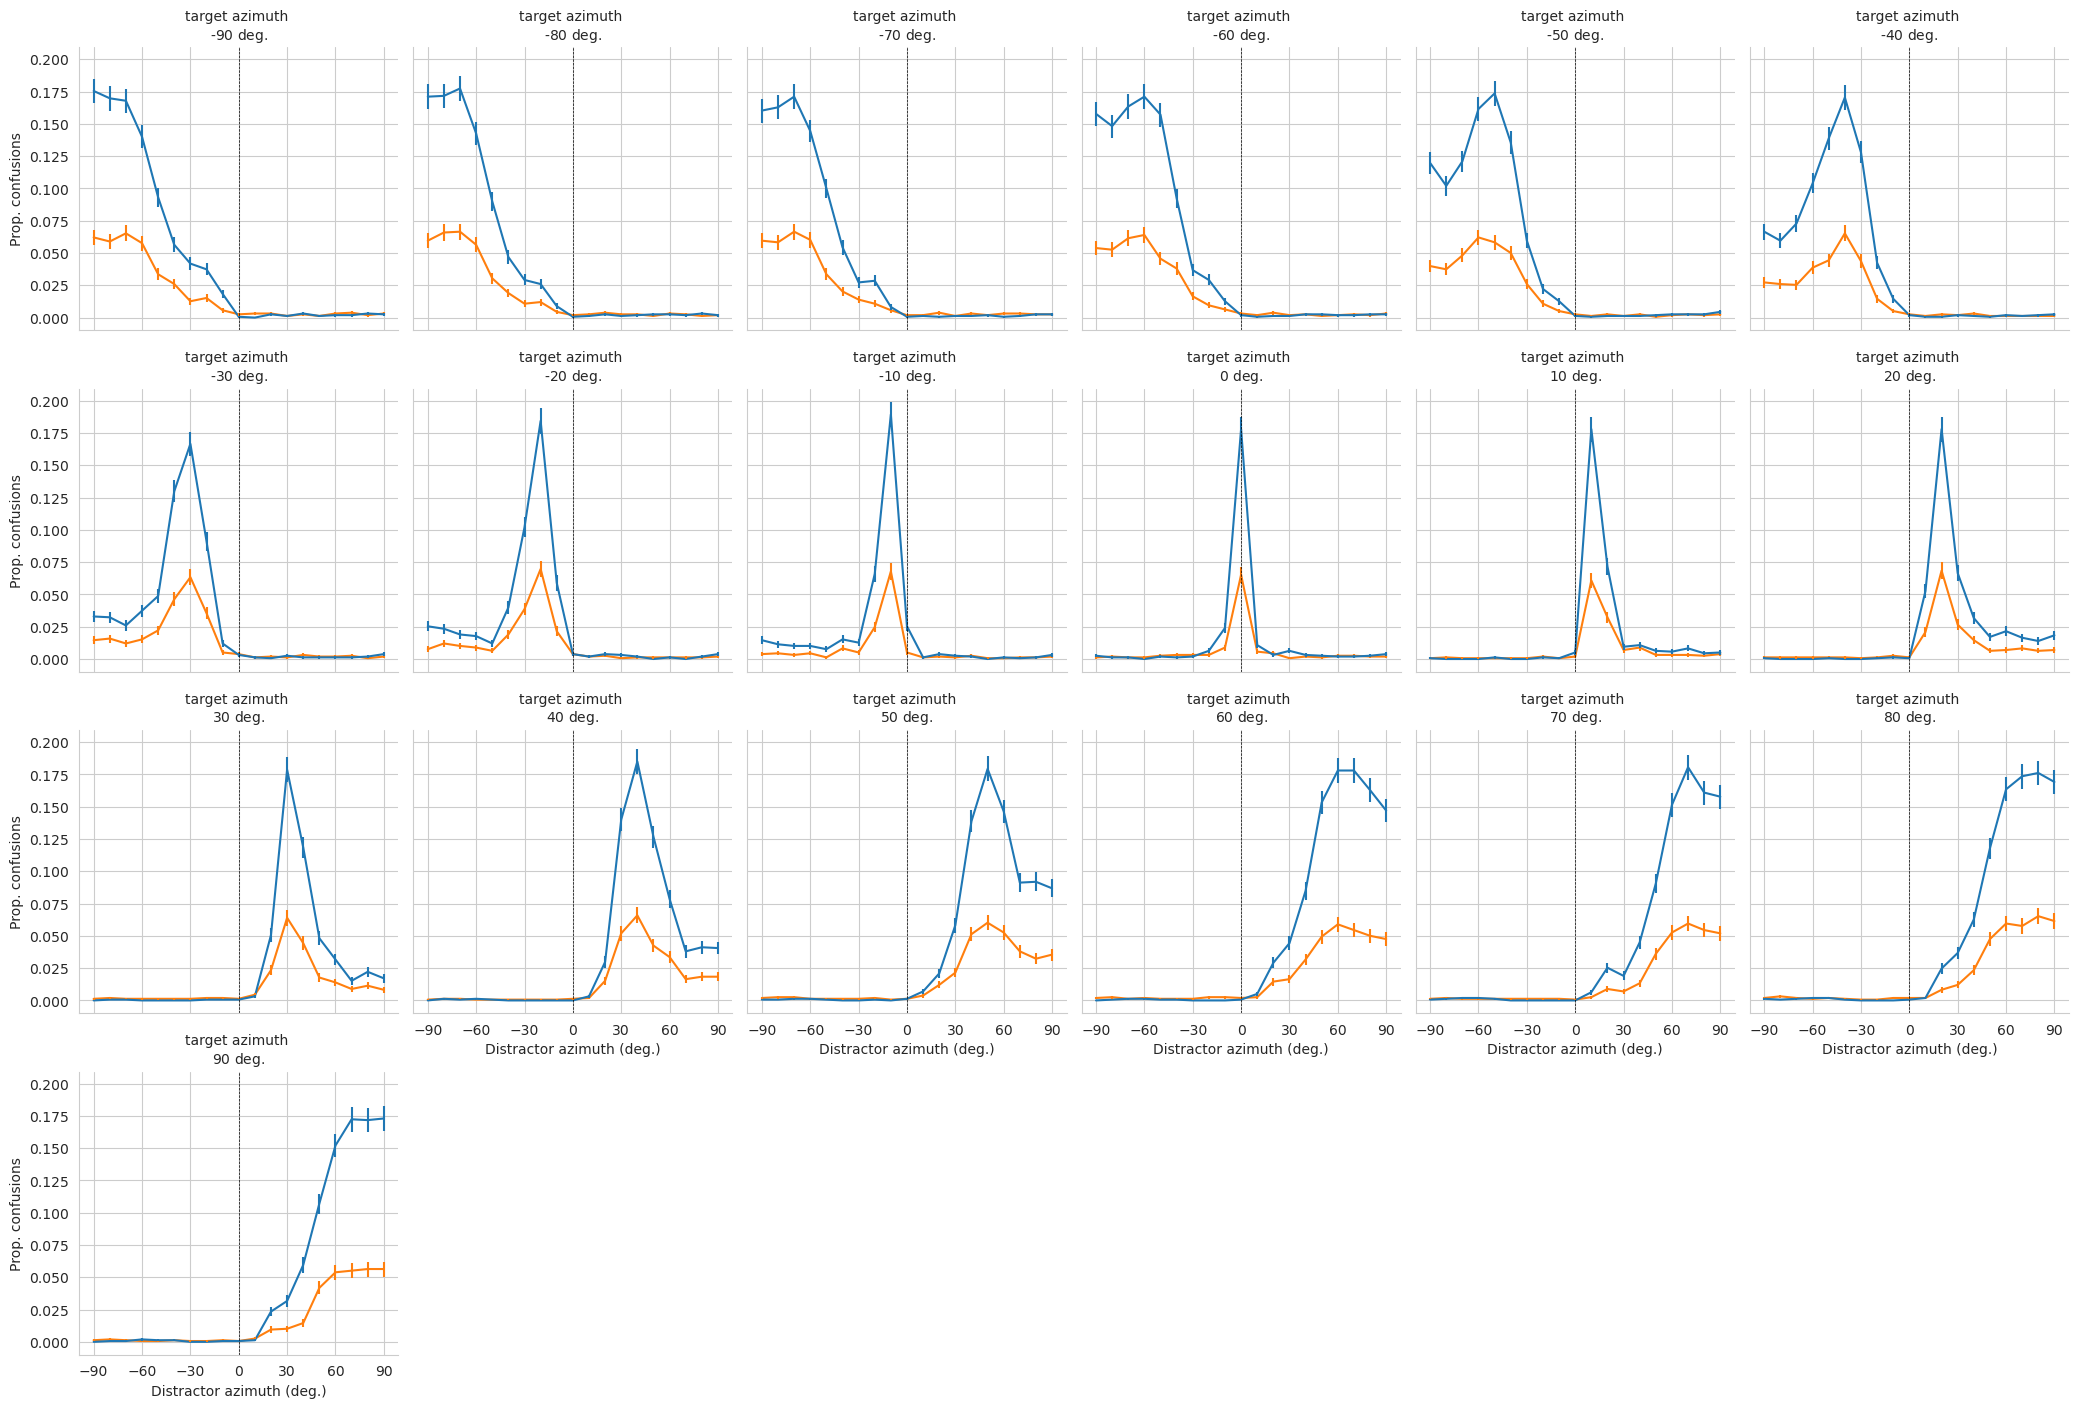

In [12]:

palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = grouped_results[(grouped_results.target_elev == 0)  & (grouped_results.distractor_elev == 0)]
g = sns.relplot(data=to_plot,
                palette=palette,
                 x='distractor_azim', y='confusions_mean', 
                 hue='gender_cond', kind='line', height=3.5,
                 col='target_azim', col_wrap=6)

# iterate through each facet of the facetgrid
for azim, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    # select the data for the facet
    data = to_plot[to_plot['target_azim'].eq(azim)]
    # select the data for each hue group
    for group, selected in data.groupby('gender_cond'):
        # plot the errorbar with the correct color for each group 
        # print(selected)
        ax.errorbar(data=selected, x="distractor_azim", y="confusions_mean",
                     yerr="confusions_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth \n{col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

In [13]:
outfig_dest = Path('ARO_2024/figures')

/tmp/ipykernel_142102/731136986.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


Text(0.5, 1.05, 'Attentional tuning in azimuth')

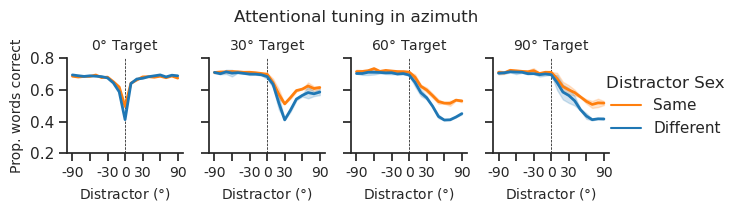

In [14]:
## Make plot with folded azimuths

sns.set_theme(style="ticks")

palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.abs_target_azim.isin([0,30,60,90])) & (grouped_results.distractor_elev == 0)]
to_plot.target_azim.unique()
to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 
fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=2, zorder=5,
                 x='folded_distractor_azim', y='accuracy_mean', 
                 hue='gender_cond', kind='line', errorbar=('se', 2),
                 col='abs_target_azim', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. words correct", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0.20, 0.81, 0.2))
xticks, xlabels =  plt.xticks()
g.set_xticklabels([-90,'', -30, 0, 30, '', 90], size = fontsize)

# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# change legend title 
g._legend.set_title('Distractor Sex')
# change handle titles 
for t, l in zip(g._legend.texts, ["Same", "Different"]):
    t.set_text(l)

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)

# plt.savefig(outfig_dest/'azimuth_tuning.svg', transparent=True, bbox_inches='tight')

Text(0.5, 1.05, 'Attentional tuning in elevation')

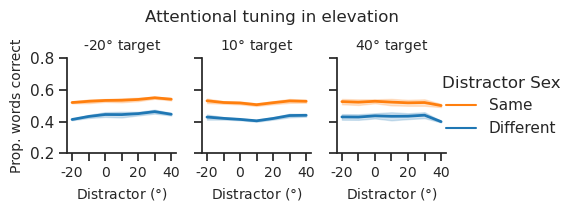

In [15]:
to_plot = grouped_results[(grouped_results.azim_delta == 0) & (grouped_results.abs_target_azim.isin([0,30,90])) & (grouped_results.target_elev != 0 )]
hue_order = ['target', 'distractor', 'co-located']


## Make plot with folded azimuths

sns.set_theme(style="ticks")

palette = {'same':'tab:blue', 'diff':'tab:orange'}  

fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=2, zorder=5,
                 x='distractor_elev', y='accuracy_mean', 
                 hue='gender_cond', kind='line', errorbar=('se', 2),
                 col='target_elev', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. words correct", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(0.20, 0.81, 0.2))
g.set_xticklabels([-20,'', 0, '', 20, '', 40], size = fontsize)

# change legend title 
g._legend.set_title('Distractor Sex')
# change handle titles 
for t, l in zip(g._legend.texts, ["Same", "Different"]):
    t.set_text(l)

# xticks, xlabels =  plt.xticks()
# g.set_xticklabels(np.arange(-90, 91, 30), size = fontsize-1)

# add x line at 0 
# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in elevation', fontsize=fontsize+2, y=1.05)
# plt.savefig(outfig_dest/'elevation_tuning.svg', transparent=True, bbox_inches='tight')


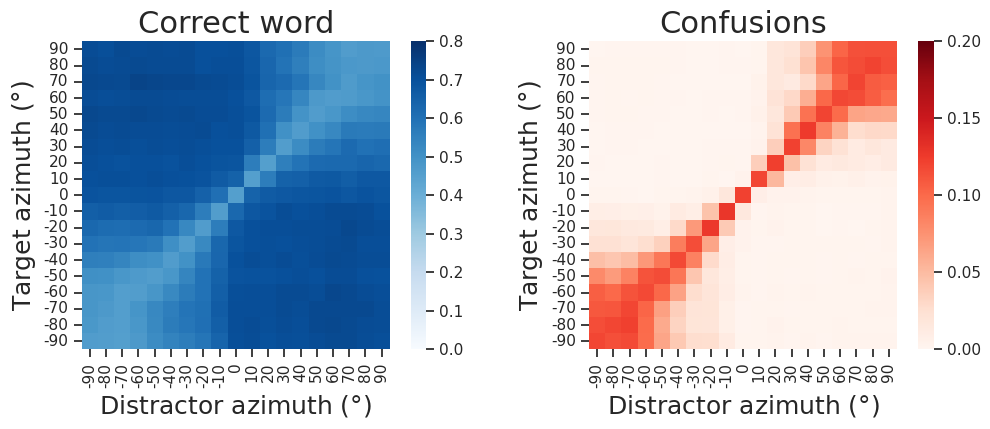

In [16]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions_mean']

fontsize=22
to_plot = grouped_results[grouped_results.target_elev.eq(0) & grouped_results.distractor_elev.eq(0)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=True,ax=axs[0])
total_con = to_plot.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.2, cmap='Reds', cbar=True,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
    ax.set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# axs[0].set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
# axs[0].set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

# make colorbar match heatmap size

# set confusions colorbar ticks to 0.5 increments
cbar_1 = axs[1].collections[0].colorbar
cbar_1.set_ticks(np.arange(0, 0.21, 0.05))


for ax in axs.flatten():
    ax.invert_yaxis()

# plt.savefig(outfig_dest/'azim_heatmaps.svg', trasnsparent=True, bbox_inches='tight')

# plt.tight_layout()

## Standard analysis plots

/tmp/ipykernel_142102/3324916956.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


Text(0.5, 1.05, 'Chance co-located trials in training')

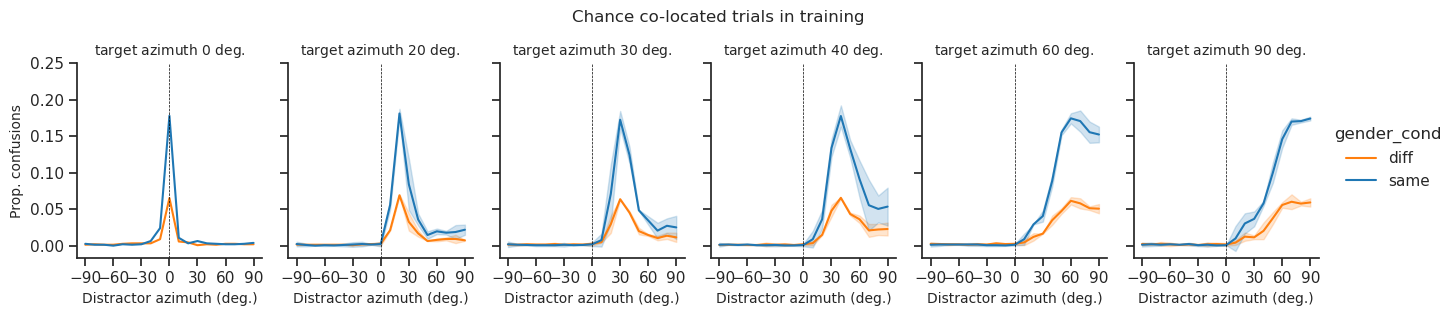

In [17]:
## Make plot with folded azimuths



palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.abs_target_azim.isin([0,20,30,40,60,90])) & (grouped_results.distractor_elev == 0)]
to_plot.target_azim.unique()
to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 
fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                 x='folded_distractor_azim', y='confusions_mean', 
                 hue='gender_cond', kind='line', errorbar=('se',2),
                 col='abs_target_azim', height=3, aspect=.75)

# iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim'].eq(azim)]
#     # select the data for each hue group
#     for group, selected in data.groupby('gender_cond'):
#         # plot the errorbar with the correct color for each group 
        
#         # print(selected)
#         ax.errorbar(data=selected, x="folded_distractor_azim", y="confusions_mean",
#                      yerr="confusions_sem", color=palette[group], marker=None, ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions", fontsize=fontsize)
g.set_titles("target azimuth {col_name} $\deg.$",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(.0, .3, 0.05))
# g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

In [16]:
grouped_results.target_azim.unique()

array([-90, -80, -70, -60, -50, -40, -30, -20, -10,   0,  10,  20,  30,
        40,  50,  60,  70,  80,  90])

# Confusion matrices for target vs distractor location 
## Spatial conditions
### target vs distractor azimuth - columns are different elevation conditions 

### target vs distractor azimuth - columns are different sex conditions 

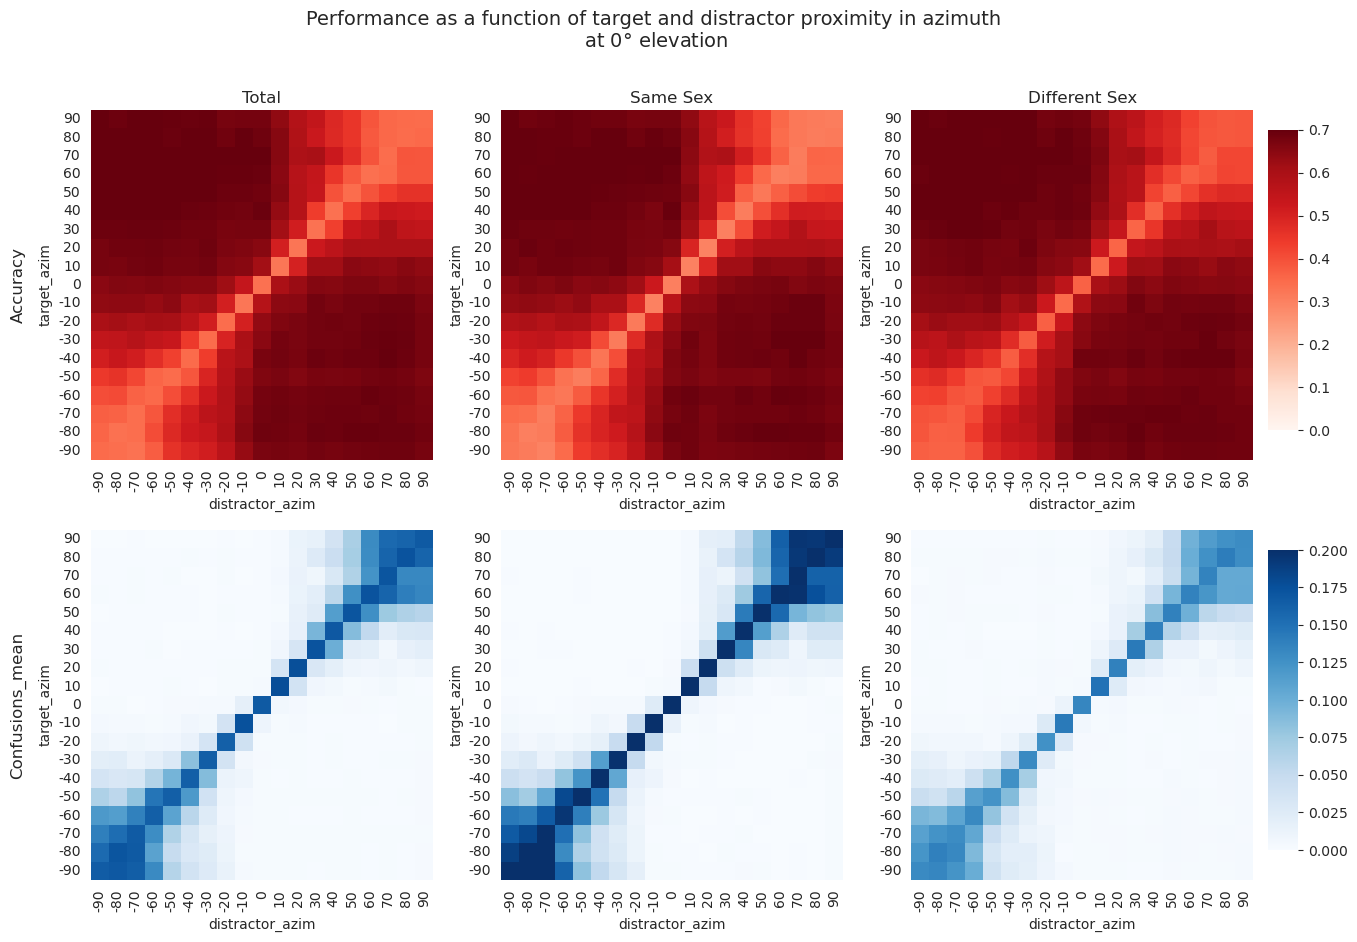

In [17]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions_mean']

to_plot = grouped_results[grouped_results.target_elev.eq(0) & grouped_results.distractor_elev.eq(0)]

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.7, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = to_plot.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.2, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex = to_plot[to_plot.gender_cond == 'same']
same_sex_acc = same_sex.groupby(['target_azim', 'distractor_azim'])['accuracy_mean'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= 0.7, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.2, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex = to_plot[to_plot.gender_cond == 'diff']
diff_sex_acc = diff_sex.groupby(['target_azim', 'distractor_azim'])['accuracy_mean'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=0.7, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.2, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor proximity in azimuth\n at $0\degree$ elevation', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()


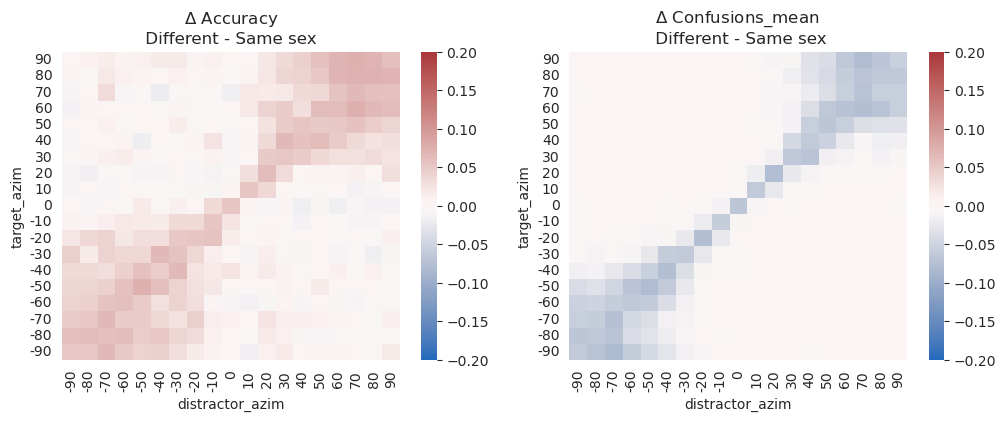

In [18]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['accuracy_mean', 'Confusions_mean']

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

diff_sex = grouped_results[grouped_results.gender_cond == 'diff']
same_sex = grouped_results[grouped_results.gender_cond == 'same']

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
sns.heatmap(diff.unstack(), vmin=-0.20, vmax=0.20, cmap='vlag', cbar=True, ax=axs[0]) #  cbar_ax=cbar_ax_1,

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['confusions_mean'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['confusions_mean'].mean()
sns.heatmap(diff.unstack(), vmin=-0.20, vmax=0.20, cmap='vlag', cbar=True,  ax=axs[1]) # cbar_ax=cbar_ax_2,

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy \n Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions_mean \n Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('Gain in performance for different-sex vs same-sex pairs', fontsize=14, y=1.05);
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

for ax in axs.flatten():
    ax.invert_yaxis()

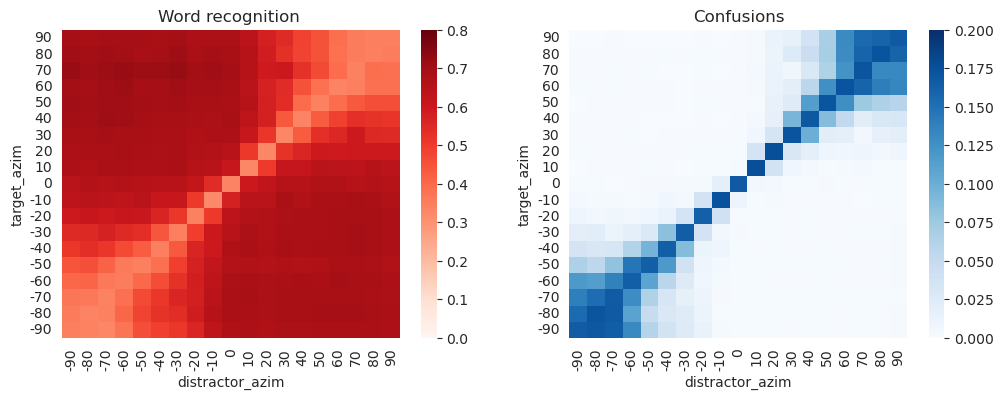

In [19]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions_mean']

to_plot = grouped_results[grouped_results.target_elev.eq(0) & grouped_results.distractor_elev.eq(0)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.8, cmap='Reds', cbar=True,  ax=axs[0])
total_con = to_plot.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.2, cmap='Blues', cbar=True,  ax=axs[1])

axs[0].set_title("Word recognition ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

for ax in axs.flatten():
    ax.invert_yaxis()


In [20]:
# # New results using updated checkpoint epoch=0-step=2000-v2.ckpt

# # plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['Accuracy', 'Confusions']

# fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

# # cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# # cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

# total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
# sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True,  ax=axs[0])

# total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
# sns.heatmap(total_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True,ax=axs[1])

# # for ax, col in zip(axs[0], cols):
# #     ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# # for ax, row in zip(axs[:, 0], rows):
# #     ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# # fig.tight_layout(rect=[0,0,.9,1])

# axs[0].set_title("Accuracy", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# # for ax, row in zip(axs[1], rows):
# axs[1].set_title("Confusions")
# axs[0].set_ylabel("Target azimuth")
# axs[1].set_ylabel("Target azimuth")
# axs[0].set_xlabel("Distractor azimuth")
# axs[1].set_xlabel("Distractor azimuth")


# plt.suptitle('Performance as a function of proximity in azimuth at $0\degree$ elevation', fontsize=14, y=1);

# for ax in axs.flatten():
#     ax.invert_yaxis()

# # plt.savefig("prelim_binaural_figs/avg_perf_confusion_at_0_elev.pdf", bbox_inches="tight")

In [21]:
# # plot all plots so far onto one figure
# # cols = ['Total', 'Same Sex', 'Different Sex']
# # rows = ['word_acc', 'Confusions']

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# # cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# # cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

# diff_sex = results[results.sex_cond == 'diff']
# same_sex = results[results.sex_cond == 'same']

# diff = diff_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean()
# sns.heatmap(diff.unstack(), vmin=-0.15, vmax=0.15, cmap='vlag', cbar=True, ax=axs[0]) #  cbar_ax=cbar_ax_1,

# diff = diff_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean()
# sns.heatmap(diff.unstack(), vmin=-0.15, vmax=0.15, cmap='vlag', cbar=True,  ax=axs[1]) # cbar_ax=cbar_ax_2,

# # for ax, col in zip(axs[0], cols):
# axs[0].set_title("$\Delta$ Accuracy \n Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# # for ax, row in zip(axs[1], rows):
# axs[1].set_title("$\Delta$ Confusions \n Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# # fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('Gain in performance for different-sex vs same-sex pairs', fontsize=14, y=1.05);

# for ax in axs.flatten():
#     ax.invert_yaxis()

# # plt.savefig("prelim_binaural_figs/diff_min_same_confusion_at_0_elev.pdf", bbox_inches="tight")

# Line plots
## Plot performance as function of separation between target and distractor 

In [20]:
grouped_results.columns

Index(['target_azim', 'target_elev', 'distractor_azim', 'distractor_elev',
       'gender_cond', 'accuracy_mean', 'accuracy_sem', 'confusions_mean',
       'confusions_sem', 'elevation_sep', 'abs_elevation_sep',
       'elevated_source', 'abs_target_azim', 'abs_distractor_azim',
       'azim_delta', 'abs_azim_delta'],
      dtype='object')

/tmp/ipykernel_1085921/1868279452.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(data=to_plot, x='distractor_elev', y='accuracy_mean',  errorbar=('se',2),


Text(0.5, 1.05, '50% co-located trials in training')

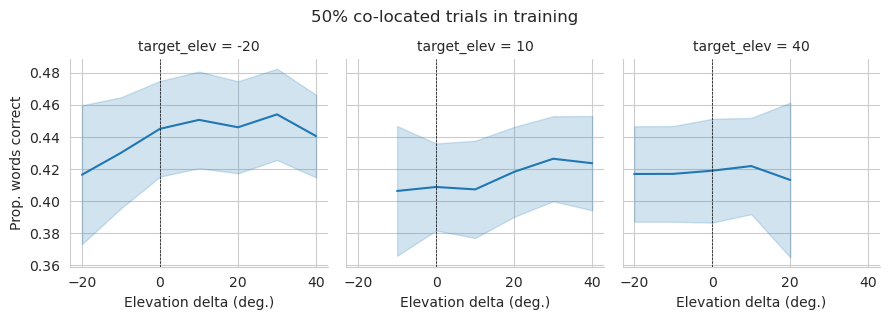

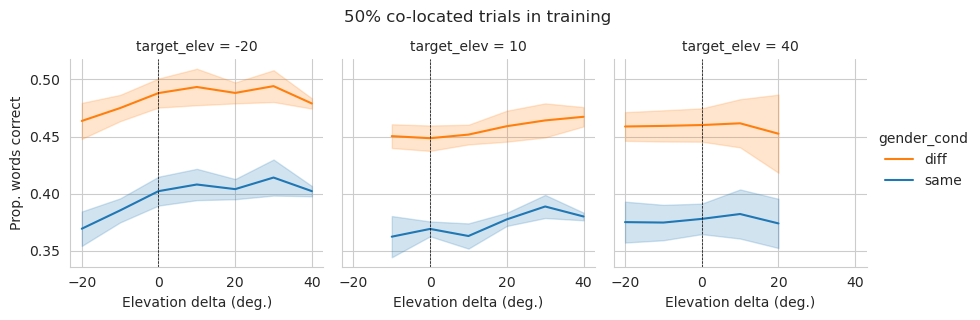

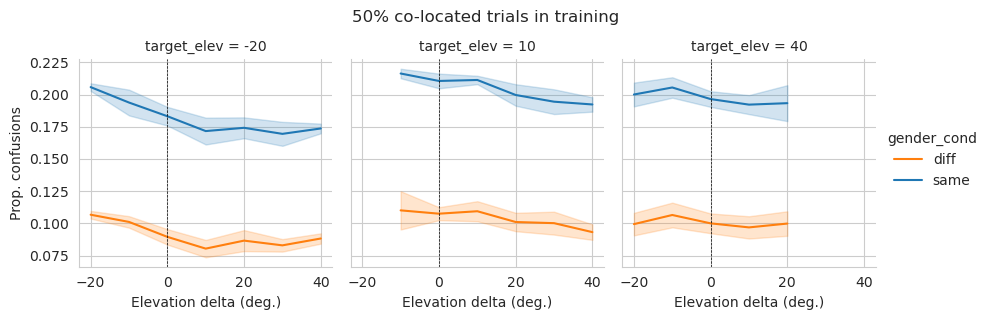

In [24]:
### Same as above, but now lines are azim delta 

palette = {'same':'tab:blue', 'diff':'tab:orange'}  


to_plot = grouped_results[(grouped_results.azim_delta == 0) & (grouped_results.abs_target_azim.isin([0,30,90])) & (grouped_results.target_elev != 0 )]
hue_order = ['target', 'distractor', 'co-located']

g = sns.relplot(data=to_plot, x='distractor_elev', y='accuracy_mean',  errorbar=('se',2),
                col='target_elev', palette=palette,
                kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Elevation delta (deg.)", "Prop. words correct")
# g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-60, 61, 20),yticks=np.arange(0.0,0.61, 0.1))
plt.suptitle('50% co-located trials in training', fontsize=fontsize+2, y=1.05)


g = sns.relplot(data=to_plot, x='distractor_elev', y='accuracy_mean', hue='gender_cond',errorbar=('se',2),
                col='target_elev', palette=palette,
                kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Elevation delta (deg.)", "Prop. words correct")
# g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-60, 61, 20),yticks=np.arange(0.0,0.61, 0.1))
plt.suptitle('50% co-located trials in training', fontsize=fontsize+2, y=1.05)

# change legend title 
# g.legend.set_title('Abs elveation delta')

g = sns.relplot(data=to_plot, x='distractor_elev', y='confusions_mean',  hue='gender_cond', errorbar=('se',2),
                col='target_elev', palette=palette,
                kind='line',  height=3)
# add x line at 0 


g.set_axis_labels("Elevation delta (deg.)", "Prop. confusions")
# g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-60, 61, 20),yticks=np.arange(0.0,0.61, 0.1))
# g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.suptitle('50% co-located trials in training', fontsize=fontsize+2, y=1.05)


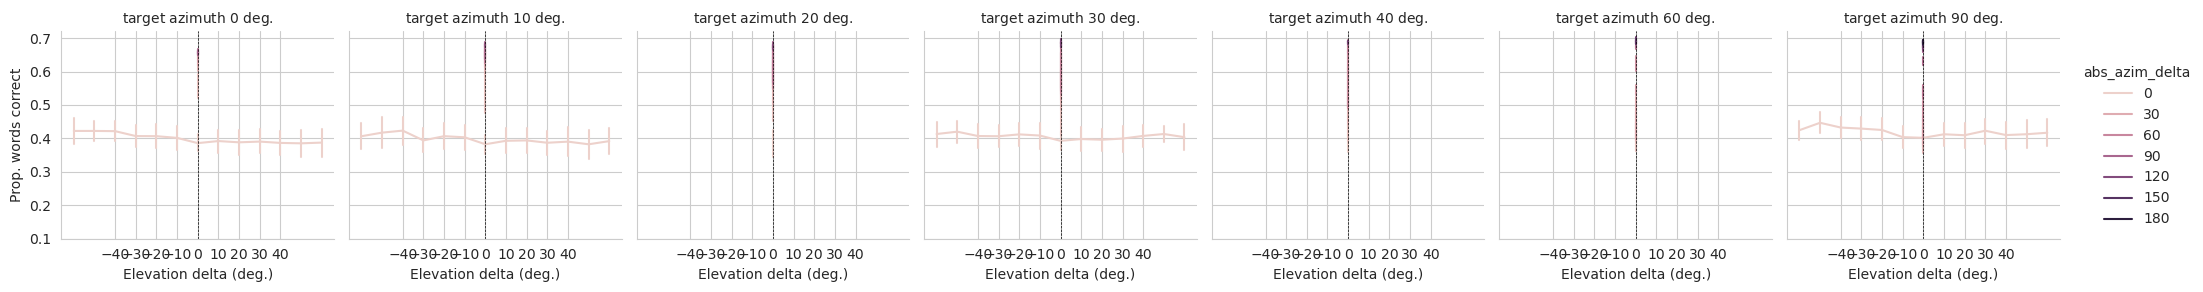

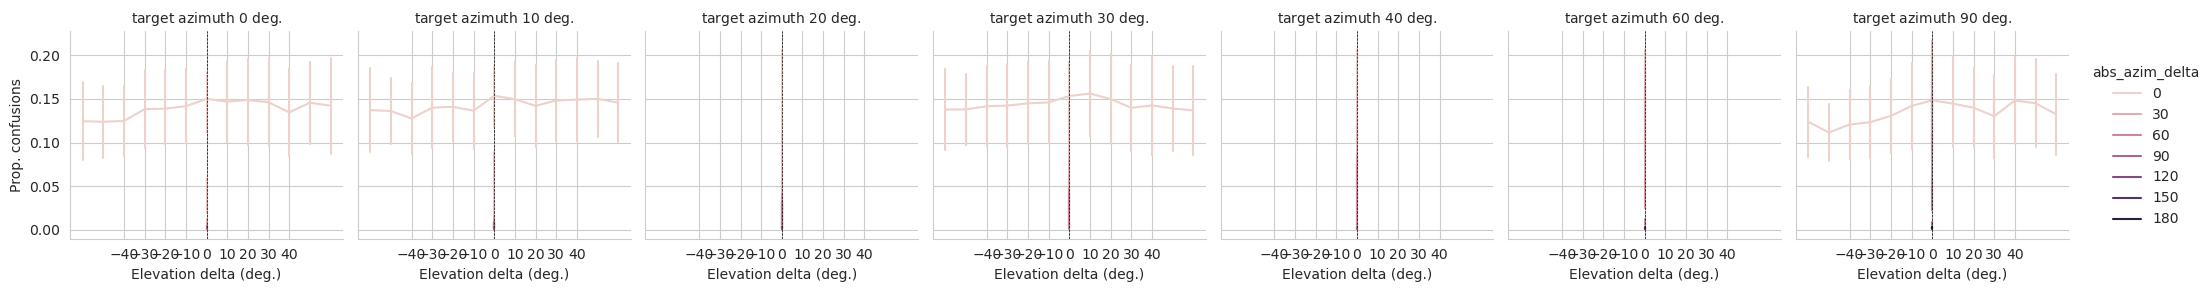

In [20]:
### Same as above, but now lines are azim delta 

to_plot = grouped_results[grouped_results.target_azim.isin([0,10,20,30,40,60,90])]
hue_order = ['target', 'distractor', 'co-located']

g = sns.relplot(data=to_plot, x='elevation_sep', y='accuracy_mean', hue='abs_azim_delta', err_style='bars',
                col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Elevation delta (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-40, 41, 10),yticks=np.arange(0.1,0.8, 0.1))

# change legend title 
# g.legend.set_title('Abs elveation delta')

g = sns.relplot(data=to_plot, x='elevation_sep', y='confusions_mean', hue='abs_azim_delta', err_style='bars',
                col='target_azim', kind='line',  height=3)
# add x line at 0 


g.set_axis_labels("Elevation delta (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-40, 41, 10))
# g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


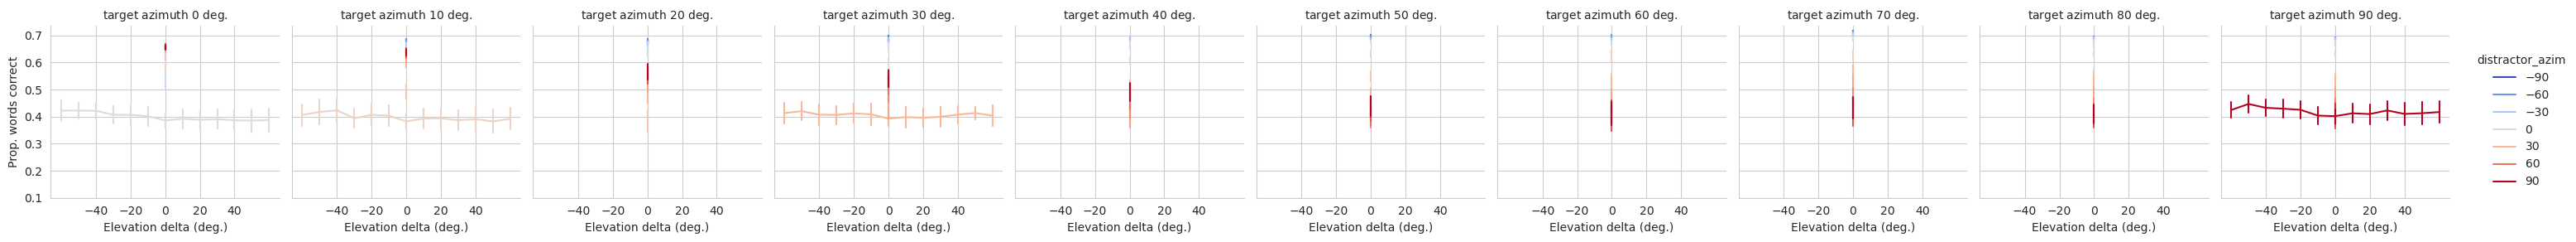

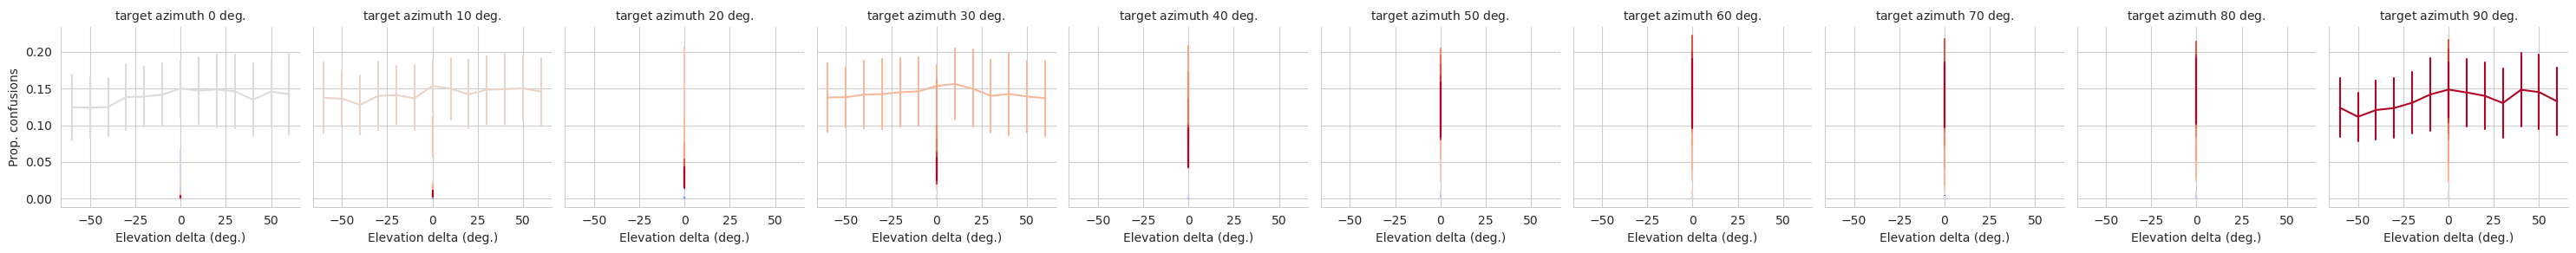

In [21]:
### Plot performance by elevation delta - colors indicate distractor azimuth, columns indicate target azimuth
to_plot = grouped_results[grouped_results.target_azim >=0]
# to_plot = to_plot[to_plot.abs_distractor_azim.isin([0, 10, 30, 90])]

# diverging palette
palette = sns.color_palette("coolwarm", as_cmap=True)

g = sns.relplot(data=to_plot, x='elevation_sep', y='accuracy_mean', hue='distractor_azim', err_style='bars', palette=palette,
                col='target_azim', kind='line', height=3)
# add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Elevation delta (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-40, 41, 20),yticks=np.arange(0.1,0.8, 0.1))

g = sns.relplot(data=to_plot, x='elevation_sep', y='confusions_mean', hue='distractor_azim', err_style='bars', palette=palette,
                col='target_azim', kind='line',  height=3)
# add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Elevation delta (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-60, 61, 20))
g.legend.remove()


ValueError: Could not interpret value `elevation_sep` for parameter `x`

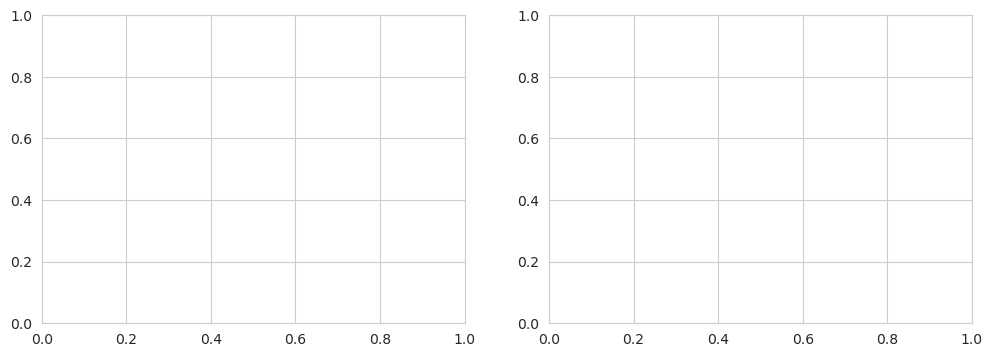

In [22]:
# to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
to_plot = results[results.target_azim.isin([0])].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='elevation_sep', y='word_acc', ax=axs[0], errorbar=('se', 2),err_style='bars',
               hue='abs_azim_delta', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='elevation_sep', y='confusions',  errorbar=('se', 2), err_style='bars',
               ax=axs[1], hue='abs_azim_delta',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
# axs[0].set_xticks(np.arange(0, 91, 30))
# axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
# axs[0].set_xlabel("Shared Azimuth")
# axs[1].set_xlabel("Shared Azimuth")




In [ ]:

# # fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# # make seaborn diverging color palette where 0 is black with 2 colors on either side 
# cmap = sns.diverging_palette(150, 275,  s=80, l=55, as_cmap=True, center='dark')

# # to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
# to_plot = results[results.target_azim.isin([0, -50, -90])]
# hue_order = ['target', 'distractor', 'co-located']

# g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='abs_elevation_sep',palette=cmap,
#                 col='target_azim', kind='line', height=3)
# # add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
# g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
# g.set_titles("target azimuth {col_name} $\deg.$")
# # set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# # change legend title 
# # g.legend.set_title('Abs elveation delta')



# g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='abs_elevation_sep', palette=cmap,
#                 col='target_azim', kind='line',  height=3)
# # add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


# g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
# g.set_titles("target azimuth {col_name} $\deg.$")
# # set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-90, 91, 30))
# g.legend.remove()
# # add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


In [ ]:

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# make seaborn diverging color palette where 0 is black with 2 colors on either side 
# cmap = sns.diverging_palette(220, 20, as_cmap=True, center='dark')

# to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.target_azim.isin([0, -50, -90])]

to_plot['elev_sep_cond'] = to_plot.abs_elevation_sep.apply(lambda x: 'co-located' if x == 0 else 'large' if x >= 20 else 'small')

hue_order = ['target', 'distractor', 'co-located']

g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='elev_sep_cond',
                col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# change legend title 
# g.legend.set_title('Abs elveation delta')



g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='elev_sep_cond', 
                col='target_azim', kind='line',  height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


In [ ]:
style_order = [0, 90, -90]
to_plot = results[results.target_azim.isin(style_order)].reset_index(drop=True)


fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], hue='sex_cond', size="target_azim")
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', size="target_azim", ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
# axs[0].set_xticks(np.arange(0, 91, 30))
# axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Azimuth detla")
axs[1].set_xlabel("Azimuth detla")




In [ ]:
## Plot for target at 00 

center_target_cond = results[results.target_azim == 0].reset_index(drop=True)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=center_target_cond, x='distractor_azim', y='word_acc', ax=axs[0], color='red') 
sns.lineplot(data=center_target_cond, x='distractor_azim', y='confusions', ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 10),np.arange(-90, 91, 10),rotation=90)
axs[1].set_xticks(np.arange(-90, 91, 10), np.arange(-90, 91, 10),rotation=90)
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




In [ ]:
style_order = [0, 90, -90]
to_plot = results[results.target_azim.isin(style_order)].reset_index(drop=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], style='target_azim', style_order=style_order, color='red') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', style='target_azim', style_order=style_order, ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




In [ ]:
results

In [ ]:
to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']
to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='joint_azim', y='word_acc', ax=axs[0], errorbar=('se', 2),err_style='bars',
               style='elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='joint_azim', y='confusions',  errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 91, 30))
axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Shared Azimuth")
axs[1].set_xlabel("Shared Azimuth")




In [ ]:
to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']
to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='joint_azim', y='word_acc', ax=axs[0], hue='elevated_source', hue_order=hue_order, palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2),err_style='bars',
               style='abs_elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='joint_azim', y='confusions', hue='elevated_source', hue_order=hue_order,palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='abs_elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 91, 30))
axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Shared Azimuth")
axs[1].set_xlabel("Shared Azimuth")




In [ ]:
# to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']
# to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=results, x='abs_azim_delta', y='word_acc', ax=axs[0], hue='elevated_source', hue_order=hue_order, palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2),err_style='bars',
               style='abs_elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=results, x='abs_azim_delta', y='confusions', hue='elevated_source', hue_order=hue_order,palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='abs_elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 181, 30))
axs[1].set_xticks(np.arange(0, 181, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Azimuth delta")
axs[1].set_xlabel("Azimuth delta")




In [ ]:
to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)

to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='joint_azim', y='word_acc', ax=axs[0], hue='sex_cond', errorbar=('se', 2),err_style='bars',
               style='elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='joint_azim', y='confusions', hue='sex_cond', errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 91, 30))
axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Shared Azimuth")
axs[1].set_xlabel("Shared Azimuth")




In [ ]:
to_plot = results[results.target_azim == 0].reset_index(drop=True)

# to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], hue='sex_cond', errorbar=('se', 2),err_style='bars',
               style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




In [ ]:
to_plot = results[results.target_azim.isin([90, -90])].reset_index(drop=True)

# to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], hue='sex_cond', errorbar=('se', 2),err_style='bars', size='target_azim',
               style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', errorbar=('se', 2), err_style='bars',size='target_azim',
               ax=axs[1], style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")


